<a href="https://colab.research.google.com/github/anjicx/Cormbobidity-Network-Analysis/blob/main/SNA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Korišćenjem mreža kormobiditeta se mogu lakše uočiti obrasci povezanosti između bolesti u odnosu na pojedinčno posmatranje bolesti. Predmet ovog rada je opis strukture mreže komorbiditeta između različitih dijagnoza na osnovu javno dostupnih matrica asocijacija. Cilj je da se korišćenjem mrežnog pristupa ispita struktura povezanosti između različitih dijagnoza, otkriju centralne dijagnoze i izdvoje zajednice međusobno povezanih dijagnoza. Odgovori na ova istraživačka pitanja mogu biti značajni doktorima i ostalom kvalifikovanom osoblju koje bi na osnovu toga moglo doneti detaljnije medicinske zaključke.

In [1]:
#install
!pip -q install statsmodels pyvis igraph

#imports
import math
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from pyvis.network import Network
from IPython.display import display, HTML

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.3 MB/s eta 0:00:00


# **Metodologija**

Matrice asocijacija su matrice log odds vrednosti logističke regresije i p vrednosti njihove statističke značajnosti, dobijenih iz preko million podataka US veterana. Primenom metoda analize mreža, dijagnoze se predstavljaju kao čvorovi, dok statistički značajne i dovoljno jake asocijacije između njih predstavljaju grane. Na ovaj način istražuje se organizacija mreže, značaj pojedinačnih dijagnoza u njenoj strukturi i postojanje grupa međusobno povezanih oboljenja.

# a)	Dostupni podaci

Nakon filtracije koju su istraživači uradili originalni set podataka je sadržao podatke od oko milion (977 183) američkih veterana. Budući da su medicinski setovi podataka setovi sa visoko osetljivim podacima, za analizu su kreirane i stavljene na raspolaganje matrice podataka koje se odnose na logističku regresiju i na p-vrednosti značaja vrednosti dobijenih logističkom regresijom.
Elementi matrice logističke regresije su vrednosti β1 dobijene logističkom regresijom. Model je dat izrazom:

Log(odds)= β1 xj+ β0, gde je:

Xj - indikator prisustva dijagnoze j,

x=0 nema dijagnoze j -> log(odds0) = β0

x=1 prisutna dijagnoza j -> log(odds1) = β1 + β0

ODUZIMANJEM DOBIJAMO -> β1=log(odd1 /odd0)=log(odds ratio)

Elementi matrice logističke regresije predstavljaju log OR (promena log odds-a), odnosno log odds povećanje za pojavu dijagnoze i kada je dijagnoza j već prisutna. Element matrice Aij je samim tim: Aij=β1=log(odds ratio).
Elementi matrice p-vrednosti su dobijeni korišćenjem Wald testa za svaku β1 dobijenu vrednost sa nultom hipotezom da je β1 =0.


In [2]:
# load data from git
if not Path("comorbidityNetworks").exists():
    !git clone https://github.com/aaronab/comorbidity_networks.git
odds = pd.read_csv("comorbidity_networks/comorbidity_odds_matrix.csv", index_col=0)
pval = pd.read_csv("comorbidity_networks/comorbidity_pmat_matrix.csv", index_col=0)

Cloning into 'comorbidity_networks'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 20 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 165.34 KiB | 1.97 MiB/s, done.
Resolving deltas: 100% (4/4), done.


# b)	Statističko modelovanje

Na osnovu matrice β1 (log odds ratio) vrednosti je kreirana korigovana matrica statistički značajnih ivica dobijenih nakon FDR (false discovery rate) testa. Ovaj test se koristi da smanji broj lažno pozitivnih veza, dobijenih zbog velikog broja sprovedenih Wald testova.

Za potrebe kasnijeg tumačenja je zatim izvršeno eksponovanje β1 .

Nakon eksponovanja, elementi matrice predstavljalju odds ratio pojave dijagnoze i ako je dijagnoza j već prisutna.
Zatim su filtrirane ivice sa ciljem da se izdvoje samo statistički značajne (p<0.05 i OR>1.5).

Budući da je u originalnoj matrici Aij uticaj dijagnoze j na i (j->i), a NetworkX očekuje Aij da je i koje predviđa j (i->j) dodatno je i transponovana matrica.

**ZAŠTO TRANSPONOVANJE?**

Budući da je u originalnoj matrici Aij uticaj dijagnoze j na i (j->i), a NetworkX očekuje Aij da je i koje predviđa j (i->j) dodatno je i transponovana matrica.

In [3]:
# fdr correction
import numpy as np #for work with matrix
from statsmodels.stats.multitest import fdrcorrection #for fdr test
import pandas as pd

P = pval.copy()
n = P.shape[0]
mask = ~np.eye(n, dtype=bool)
pvals = P.values[mask]
_, qvals = fdrcorrection(pvals)

Q = np.zeros(P.shape, dtype=float)
Q[mask] = qvals
qmat = pd.DataFrame(Q, index=P.index, columns=P.columns)

# odds ratio and adjacency matrix
OR = np.exp(odds)
min_or = 1.5
alpha = 0.05

mask_edges = (qmat < alpha) & (OR > min_or)
A_or = OR.where(mask_edges, other=0)
A_adj = A_or.T

# c)	Mrežna analiza

Od matrice OR statistički značajnih ivica kormobiditeta je kreiran usmereni graf kormobiditeta. Čvorovi predstavljaju medicinske i psihičke dijagnoze, a ivice nam označavaju koliko je veći odds da se u prisustvu i-te dijagnoze desi j u odnosu na to u odsustvu i. Na osnovu naziva čvorova su podeljeni čvorovi u one koji su vezani za psihičke i fizičke bolesti, a zatim su im dodeljeni medicinski kraći nazivi. Nakon kreiranja grafa, ispituje se broj ivica i čvorova kod kreiranog grafa i podgrafova.


In [4]:
# build graph
G = nx.from_pandas_adjacency(A_adj, create_using=nx.DiGraph)
print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())
for edge in list(G.edges(data=True))[:10]:
    print(edge)

nodes: 95 edges: 1327
('AHRQ_AbdominalHernia_DT', 'AHRQ_BiliaryTractDs_DT', {'weight': 1.7510259052116521})
('AHRQ_AbdominalHernia_DT', 'AHRQ_DisOfVeins_DT', {'weight': 1.5707891730630459})
('AHRQ_AbdominalHernia_DT', 'AHRQ_LowerGIDO_DT', {'weight': 1.7726702678282367})
('AHRQ_AbdominalHernia_DT', 'AHRQ_OthGIDO_DT', {'weight': 1.7065066422385244})
('AHRQ_AbdominalHernia_DT', 'AHRQ_UpperGIDO_DT', {'weight': 1.8640905036760718})
('AHRQ_AbdominalHernia_DT', 'cancerdxDT', {'weight': 1.5615514362698935})
('AHRQ_AcquiredDeformities_DT', 'AHRQ_InfectiveArthritis_DT', {'weight': 1.7400949708974736})
('AHRQ_AcquiredDeformities_DT', 'AHRQ_JointDisorderTraumarelated_', {'weight': 1.515271796604436})
('AHRQ_AcquiredDeformities_DT', 'AHRQ_Mycoses_DT', {'weight': 1.657085345643728})
('AHRQ_AcquiredDeformities_DT', 'AHRQ_NontraumaticJointDO_DT', {'weight': 1.5747635229776251})


In [5]:
# mental and physical split
cols = A_adj.columns
nepec_re = r"^NEPEC_"
ahrq_mental_re = r"^AHRQ_(?:AdjustmentDO|AttentionDeficitDO|ImpulseControlDONEC|PersonalityDO|SuicideAndSelfInjury|DementiaAndOthDO|DevelopmentalDO|DOInChildhood)_DT$"

mental_mask = cols.str.contains(nepec_re, regex=True) | cols.str.contains(ahrq_mental_re, regex=True)
mental_cols = cols[mental_mask].tolist()
physical_cols = cols[~mental_mask].tolist()

In [6]:
# mental subgraph

mental_set = set(mental_cols)
mental_nodes = []
for n in G.nodes():
    if str(n) in mental_set:
        mental_nodes.append(n)

G_m = G.subgraph(mental_nodes).copy()
print("nodes mental:", G_m.number_of_nodes(), "edges:", G_m.number_of_edges())

nodes mental: 17 edges: 100


In [7]:
#  physical subgraph

physical_set = set(physical_cols)
physical_nodes = []
for n in G.nodes():
    if str(n) in physical_set:
        physical_nodes.append(n)

G_p = G.subgraph(physical_nodes).copy()
print("nodes physical:", G_p.number_of_nodes(), "edges:", G_p.number_of_edges())

nodes physical: 78 edges: 928


REZULTAT: Celokupni graf sadrži 95 čvorova i 1327 ivica. Podgraf psihičkih bolesti ima 17 čvorova i 100 ivica, dok podgraf somatskih bolesti ima 78 čvorova i 928 ivica.

***MERE CENTRALNOSTI***

Pre klasterovanja je sprovedena analiza mera centralnosti na psihijatrijskom podgrafu (G_m) da bi se identifikovale dijagnoze sa ključnim pozicijama i ulogama unutar psihijatrijske mreže komorbiditeta. Analiza je sprovedena na nivou podgrafa jer broj čvorova omogućava bolju interpretaciju rezultata. Korišćene mere centralnosti su in-strength, out-strength,closeness i betweenness.

In strength se dobija sumiranjem jačine ulaznih veza, a out strength se dobija sumiranjem izlaznih veza. In strength pokazuje u kojoj meri se druge dijagnoze asociraju sa datom dijagnozom i čvorovi sa visokom vrednošću in-strength su označeni kao ciljne dijagnoze (target). S druge strane, out strength pokazuje u kojoj meri data dijagnoza se asocira sa drugim dijagnozama i čvorovi sa visokom vrednošću out-strength su označeni kao prediktori.

Betweenness nam prikazuje potencijalnu ulogu dijagnoze kao mosta ili posrednika između drugih dijagnoza u mreži, a closeness meri koliko brzo data dijagnoza može dostići ostale u mreži.



ZAŠTO RECIPROČNA VREDNOST?

Budući da se obe mere zasnivaju na najkraćim putevima, distanca je transformisana da bude recipročna vrednost OR-a: distanca= 1/log(OR+ε) Bez transformacije bi veći OR značio kod betweeness i closeness veća distanca (putanja), a to je obrnuto jer ovde je jača veza ako je OR veći.

In [8]:
# distance for the shortest path measures
eps = 1e-12
for u, v, d in G.edges(data=True):
    w = d.get("weight", 1.0)
    d["distance"] = 1.0 / (math.log1p(w) + eps)

In [9]:
# function for centralities
def centralities_for_graph(G0):
    out_strength = dict(G0.out_degree(weight="weight"))
    in_strength = dict(G0.in_degree(weight="weight"))
    in_close = nx.closeness_centrality(G0, distance="distance")
    out_close = nx.closeness_centrality(G0.reverse(), distance="distance")
    betw = nx.betweenness_centrality(G0, weight="distance", normalized=True)
    return out_strength, in_strength, in_close, out_close, betw

In [10]:
# dataframe from centralities
def centralities_df(G0, graph_name):
   out_strength, in_strength, in_close, out_close, betw = centralities_for_graph(G0)

   df = pd.DataFrame({
        "out_strength": pd.Series(out_strength),
        "in_strength": pd.Series(in_strength),
        "in_close": pd.Series(in_close),
        "out_close": pd.Series(out_close),
        "betw": pd.Series(betw),
    })
   df = df.reset_index().rename(columns={"index": "node"})
   return df

In [12]:
# density
def densityFunction(G):
    return nx.density(G)
print("Density of the diseases graph: ", densityFunction(G))
print("Density of the physiological disease graph: ", densityFunction(G_p))
print("Density of the psychological disease graph: ", densityFunction(G_m))

Density of the diseases graph:  0.14860022396416572
Density of the physiological disease graph:  0.15451215451215453
Density of the psychological disease graph:  0.36764705882352944


REZULTAT: Gustina celoukupnog grafa je slična gustini podgrafa somatskih bolesti (približno 0.15) , dok je gustina podgrafa psihičkih bolesti značajno veća (0.37). Budući da graf psihičkih bolesti sadrži manji broj čvorova, a ima značajan broj ivica, ovakav rezultat se

In [35]:
# dataframes for graphs
df_m = centralities_df(G_m, "mental")

In [65]:
# top k
def topk(df, metric, k=3):
    return (
        df.sort_values(metric, ascending=False)
          .loc[:, ["node", metric]]
          .head(k)
    )

print("How well-positioned a psychiatric diagnosis is to be reached by other psychiatric diagnosis: ")
print(topk(df_m, "in_close"))
print(" ")
print("How well-positioned a psychiatric diagnosis is is to reach other psychiatric diagnosis:")
print(topk(df_m, "out_close"))
print(" ")
print("How centrally a a psychiatric diagnosis lies on important paths between other psychiatric diagnosis: ")
print(topk(df_m, "betw"))


How well-positioned a psychiatric diagnosis is to be reached by other psychiatric diagnosis: 
                            node  in_close
11         AHRQ_PersonalityDO_DT  0.695652
2   AHRQ_SuicideAndSelfInjury_DT  0.666667
0                 NEPEC_DXDRG_DT  0.640000
 
How well-positioned a psychiatric diagnosis is is to reach other psychiatric diagnosis:
                       node  out_close
4           NEPEC_DXODep_DT   1.000000
7  AHRQ_DementiaAndOthDO_DT   0.800000
6             NEPEC_PTSD_DT   0.761905
 
How centrally a a psychiatric diagnosis lies on important paths between other psychiatric diagnosis: 
                           node      betw
4               NEPEC_DXODep_DT  0.261272
0                NEPEC_DXDRG_DT  0.210353
2  AHRQ_SuicideAndSelfInjury_DT  0.112158


In [36]:
# node roles
def add_strength_role(df, in_col="in_strength", out_col="out_strength", q=0.75):
    df = df.copy()
    in_thr = df[in_col].quantile(q)
    out_thr = df[out_col].quantile(q)

    def strength_role(row):
        high_in = row[in_col] >= in_thr
        high_out = row[out_col] >= out_thr

        if high_in and high_out:
            return "hub"
        elif high_out and not high_in:
            return "predictor"
        elif high_in and not high_out:
            return "target"
        else:
            return "other"

    df["role"] = df.apply(strength_role, axis=1)
    return df



In [64]:
df_m_roles = add_strength_role(df_m)

df_m_roles["strength_balance"] = (
    (df_m_roles["out_strength"] - df_m_roles["in_strength"])/(df_m_roles["out_strength"] + df_m_roles["in_strength"] + 1e-9)
)
#print( df_m_roles.columns)


In [40]:
top_predictors = (
    df_m_roles[df_m_roles["role"] == "predictor"][["node", "in_strength", "out_strength", "role", "strength_balance"]]
    .sort_values("out_strength", ascending=False)
    .reset_index(drop=True)
)
top_predictors.index += 1

print("Predictors:")
print(top_predictors)

Predictors:
                       node  in_strength  out_strength       role  \
1           NEPEC_DXODep_DT    10.134034     49.145493  predictor   
2  AHRQ_DementiaAndOthDO_DT    10.558107     31.692761  predictor   
3             NEPEC_PTSD_DT     8.201442     27.939517  predictor   
4            NEPEC_DXDRG_DT    21.659593     25.502704  predictor   

   strength_balance  
1          0.658093  
2          0.500218  
3          0.546141  
4          0.081487  


In [42]:
top_hubs = (
    df_m_roles[df_m_roles["role"] == "hub"][["node", "in_strength", "out_strength", "role","strength_balance"]]
    .reset_index(drop=True)
)
top_predictors.index += 1

print("Hubs:")
print(top_hubs)

Hubs:
              node  in_strength  out_strength role  strength_balance
0  NEPEC_AFBPDX_DT    22.668503     23.458959  hub          0.017136


In [43]:
top_targets = (
    df_m_roles[df_m_roles["role"] == "target"][["node", "in_strength", "out_strength", "role","strength_balance"]]
    .sort_values("in_strength", ascending=False)
    .reset_index(drop=True)
)
top_targets.index += 1

print("Targets:")
print(top_targets)

Targets:
                           node  in_strength  out_strength    role  \
1  AHRQ_SuicideAndSelfInjury_DT    27.750829     15.735176  target   
2         AHRQ_PersonalityDO_DT    27.434480     19.398785  target   
3                 NEPEC_SCHZ_DT    26.552942     21.890029  target   
4       AHRQ_DevelopmentalDO_DT    21.719833     14.100193  target   

   strength_balance  
1         -0.276311  
2         -0.171581  
3         -0.096256  
4         -0.212720  


In [46]:
# short labels
shortnamevec = [
    "Her","Def","Adj","Ane","Ast","ADHD","Bac","Bil","Bur","NIn","CVD","COPD","Ulc","Coag",
    "Coma","CIj","Dem","Dev","Art","Mou","Hea","Uri","Vei","WBC","Lip","Jaw","Ch","Ear",
    "Ep","Eye","Ele","Fr","GIH","Gou","HA","NSC","HTN","Imm","Imp","ArI","IIn","BIj","TJ",
    "Liv","LGI","Myc","NTJ","Gas","Nut","Wou","Ost","Bone","Con","End","GIO","HeO","InO",
    "SInf","IjO","LRO","NSO","NuO","SkO","URO","Pan","Par","PFr","Per","Ple","Poi","RF",
    "RIn","SIn","Spi","Bac","Spr","Sui","SuIj","Lup","Thy","UGI","Vir","Alc","Drg","Sch",
    "MDD","BPD","PTSD","DepO","AnxO","GAD","DM","Neo","Con","Gen"
]

cols = qmat.columns
assert len(cols) == len(shortnamevec), "Some column names are missing"
assert len(cols) == len(shortnamevec), "Short names have duplicates"

label_map = dict(zip(cols, shortnamevec))

Vizuelni prikaz na osnovu in_strength i out_strength kod grafa psihičkih bolesti

In [72]:
def draw_top_edges_by_metric(
    H,
    df_metrics,
    label_map,
    metric_col="in_strength",   #default da bude
    top_n_edges=100,
    base_size=200,
    size_scale=40,
    layout="kamada_kawai",
    layout_seed=1,
    layout_k=6.0,
    layout_scale=3.0,
    cmap=plt.cm.Blues,
    figsize=(9, 7),
):
    def edge_weight(edge_tuple):
        return edge_tuple[2].get("weight", 0)

    def make_short_labels(G_sub, label_map):
        return {nodeId: label_map.get(nodeId, str(nodeId)) for nodeId in G_sub.nodes()}

    edges_sorted = sorted(H.edges(data=True), key=edge_weight, reverse=True)
    top_edges = edges_sorted[:top_n_edges]

    H2 = nx.DiGraph()
    H2.add_edges_from(top_edges)

    metric_dict = df_metrics.set_index("node")[metric_col].to_dict()
    node_values = [metric_dict.get(n, 0) for n in H2.nodes()]
    node_sizes = [base_size + size_scale * metric_dict.get(n, 0) for n in H2.nodes()]

    labels_short = make_short_labels(H2, label_map)

    plt.figure(figsize=figsize)

    if layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(H2)
        pos = {n: (xy[0] * layout_scale, xy[1] * layout_scale) for n, xy in pos.items()}
    else:
        pos = nx.spring_layout(H2, seed=layout_seed, k=layout_k)

    nx.draw_networkx_nodes(
        H2, pos,
        node_size=node_sizes,
        node_color=node_values,
        cmap=cmap,
        edgecolors="black",
        linewidths=0.5
    )

    nx.draw_networkx_edges(
        H2, pos,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=12,
        width=0.8,
        alpha=0.35,
        edge_color="gray",
        min_source_margin=2,
        min_target_margin=2
    )

    nx.draw_networkx_labels(
        H2, pos,
        labels=labels_short,
        font_size=8
    )

    plt.axis("off")
    plt.show()

GRAF NA OSNOVU IN STRENGTH PSIHIČKIH DIJAGNOZA PODGRAFA:

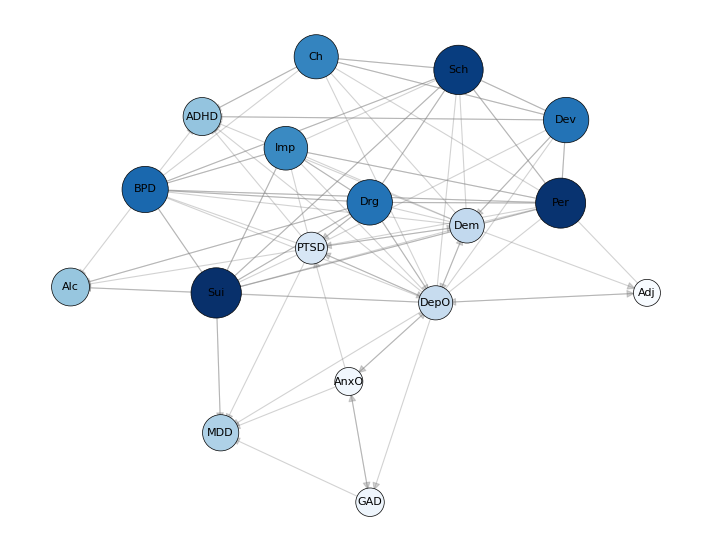

In [73]:
draw_top_edges_by_metric(
    H=H,
    df_metrics=df_m,
    label_map=label_map,
    metric_col="in_strength",
)

Interpretacija rezultata:

Prema apsolutnoj vrednosti in-strength izdvajaju se sledeće dijagnoze kao potencijalne ciljne dijagnoze: suicidalno ponašanje,poremećaj ličnosti, šizofreni poremećaj i razvojni poremećaj.

GRAF NA OSNOVU OUT STRENGTH PSIHIČKIH DIJAGNOZA PODGRAFA:

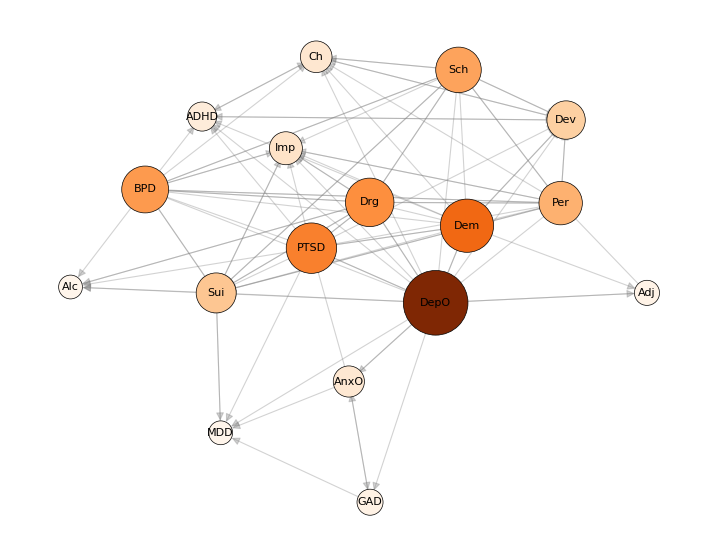

In [77]:
draw_top_edges_by_metric(
    H=H,
    df_metrics=df_m,
    label_map=label_map,
    metric_col="out_strength",
    cmap=plt.cm.Oranges,
)

GRAF NA OSNOVU BETWEENESS PSIHIČKIH DIJAGNOZA PODGRAFA:

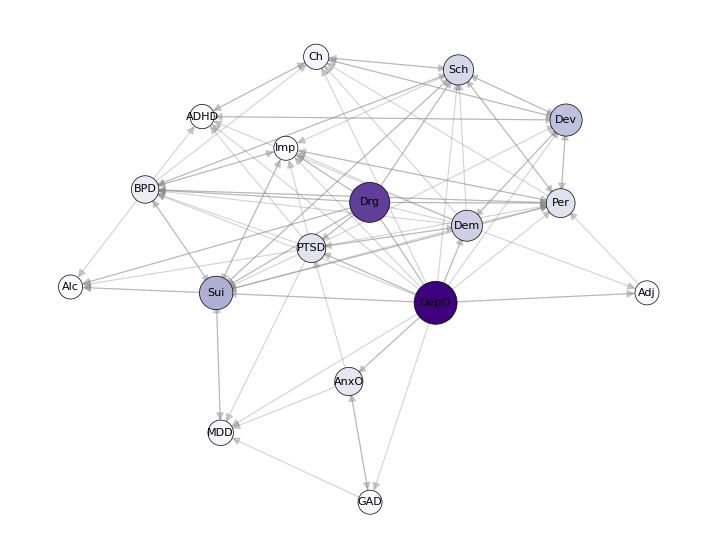

In [76]:
draw_top_edges_by_metric(
    H=H,
    df_metrics=df_m,
    label_map=label_map,
    metric_col="betw",
    base_size=300,
    size_scale=2500,
    cmap=plt.cm.Purples,
)

Interpretacija rezultata:

Posmatrajući apsolutnu vrednost out-strength-a i balans između in i out strength-a, Minor depression, dementia i PTSD se ističu u ulozi prediktora.

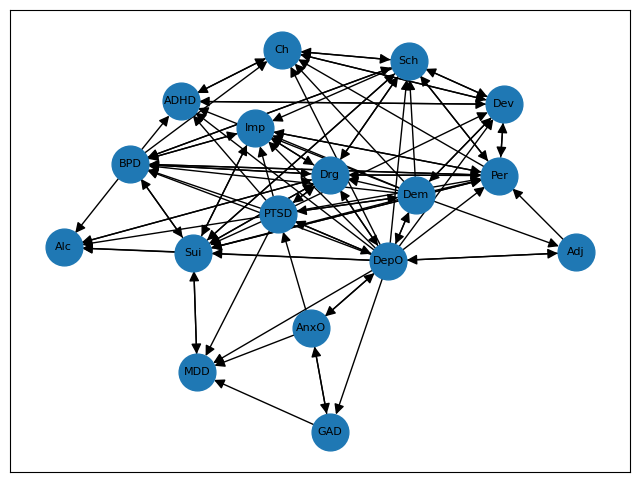

In [54]:
# kamada-kawai layout
plt.figure(figsize=(8, 6))
pos = nx.kamada_kawai_layout(H2)
scale = 3.0
pos = {n: (xy[0] * scale, xy[1] * scale) for n, xy in pos.items()}

nx.draw_networkx_nodes(H2, pos, node_size=700)
nx.draw_networkx_edges(
    H2, pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=15,
    width=1,
    node_size=700,
    min_source_margin=2,
    min_target_margin=2
)

labels_short = make_short_labels(H2, label_map)
nx.draw_networkx_labels(H2, pos, labels=labels_short, font_size=8)

plt.show()

In [ ]:
# cross-edge counts
def count_cross_edges_in_graph(G, mental_set, physical_set):
    m2p = 0
    p2m = 0
    m2m = 0
    p2p = 0
    other = 0

    for u, v in G.edges():
        u_is_m = str(u) in mental_set
        v_is_m = str(v) in mental_set
        u_is_p = str(u) in physical_set
        v_is_p = str(v) in physical_set

        if u_is_m and v_is_p:
            m2p += 1
        elif u_is_p and v_is_m:
            p2m += 1
        elif u_is_m and v_is_m:
            m2m += 1
        elif u_is_p and v_is_p:
            p2p += 1
        else:
            other += 1

    return {
        "mental→physical": m2p,
        "physical→mental": p2m,
        "mental→mental": m2m,
        "physical→physical": p2p,
        "total_edges": G.number_of_edges()
    }

counts = count_cross_edges_in_graph(G, mental_set, physical_set)
print(counts)

{'mental→physical': 227, 'physical→mental': 72, 'mental→mental': 100, 'physical→physical': 928, 'other': 0, 'total_edges': 1327}


In [ ]:
# top mental to physical outgoing edges
def top_cross_out_degree(G, mental_set, physical_set, topk=10):
    cnt = Counter()
    for u, v in G.edges():
        if str(u) in mental_set and str(v) in physical_set:
            cnt[u] += 1
    return cnt.most_common(topk)

print(top_cross_out_degree(G, mental_set, physical_set, topk=10))

[('NEPEC_DXODep_DT', 75), ('AHRQ_DementiaAndOthDO_DT', 48), ('NEPEC_SCHZ_DT', 29), ('NEPEC_DXDRG_DT', 26), ('NEPEC_PTSD_DT', 15), ('AHRQ_DevelopmentalDO_DT', 14), ('AHRQ_PersonalityDO_DT', 9), ('NEPEC_AFBPDX_DT', 5), ('AHRQ_SuicideAndSelfInjury_DT', 3), ('NEPEC_DXALC_DT', 2)]


In [ ]:
!pip -q install igraph leidenalg scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 26.9 MB/s eta 0:00:00


In [ ]:
#Transformacija u neusmereni graf da moze i za npr samo psihickih bolesti posmatranje kasnije
def to_undirected_projection_mean(G):
  #napravi neusmeren graf i doda cvorove usmerenog
    H = nx.Graph()#neusmeren graf
    H.add_nodes_from(G.nodes(data=True))#doda cvorove usmerenog
    loadedEdges=set()#SKUP UCITANIH IVICA
    for u,v in G.edges():
        a,b=sorted([u,v])#da uvek gleda jedan kao u drugi kao v i uv il vu je nebitno
        if (a,b) in loadedEdges:
            continue
        loadedEdges.add((a, b))
        w_uv = float(G[u][v].get("weight", 0.0)) if G.has_edge(u,v) else 0.0
        w_vu = float(G[v][u].get("weight", 0.0)) if G.has_edge(v,u) else 0.0
        w = (w_uv + w_vu) / 2.0
        if w > 0:
            H.add_edge(a, b, weight=w)
    return H

In [ ]:
H_m= to_undirected_projection_mean(G_m)# mental undirected subgraph
H_p= to_undirected_projection_mean(G_p)# physical diseases undirected subgraph

In [ ]:
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
from sklearn.metrics import normalized_mutual_info_score
import numpy as np
#POMOCNE FJE

def comms_to_map(comms):
    """
    list[set] -> dict node -> community_id
    """
    comm_map = {}
    for cid, nodeset in enumerate(comms):
        for n in nodeset:
            comm_map[n] = cid#dodeljulje dict cvor:klaster kojem pripada id
    return comm_map

def comm_map_to_labels(comm_map, nodes_order): ##JJ: nisam razumela sta ova f. radi i cemu sluzi
    """
    dict node->cid -> lista labela po fiksnom redosledu čvorova
    (treba za NMI)
    """
    return [comm_map[n] for n in nodes_order] #za dict cvor:klaster kojem pripada id
#NMI

In [ ]:

#Louvain sa podesavanjem hiperparametara
def louvain_sweep(H, resolutions, seeds, weight="weight"):
    nodes_order = list(H.nodes())  #fiksan redosled čvorova(za NMI)
    rows = []
    labels_by_res = {res: [] for res in resolutions}
    comms_by_res_seed = {}

    for res in resolutions:
        for seed in seeds:
            comms = louvain_communities(H, weight=weight, resolution=res, seed=seed)
            comms_by_res_seed[(res, seed)] = comms

            comm_map = comms_to_map(comms)

            #labels u fiksnom redosledu čvorova
            labels = comm_map_to_labels(comm_map, nodes_order)
            labels_by_res[res].append(labels)

            #modularity za ovaj run
            Q = modularity(H, comms, weight=weight, resolution=res)

            rows.append({
                "resolution": res,
                "seed": seed,
                "n_communities": len(comms),
                "modularity": float(Q),
                "sizes": sorted([len(c) for c in comms], reverse=True)
            })

    df_runs = pd.DataFrame(rows)

    #rezime po resolution (stabilnost + kvalitet)
    summary_rows = []
    for res in resolutions:
        sub = df_runs[df_runs["resolution"] == res]
        k_mode = int(sub["n_communities"].mode().iloc[0])  # najčešći k
        k_mode_freq = int((sub["n_communities"] == k_mode).sum())

        summary_rows.append({
            "resolution": res,
            "runs": len(sub),
            "k_mode": k_mode,
            "k_mode_freq": k_mode_freq,
            "k_min": int(sub["n_communities"].min()),
            "k_max": int(sub["n_communities"].max()),
            "modularity_mean": float(sub["modularity"].mean()),
            "modularity_std": float(sub["modularity"].std(ddof=0)),
        })

    df_summary = pd.DataFrame(summary_rows).sort_values("resolution").reset_index(drop=True)
    return df_runs, df_summary, comms_by_res_seed

In [ ]:
def representative_labels_by_resolution(df_runs, comms_by_res_seed, H, weight="weight"):
    """
    Za svaku rezoluciju uzima run sa max modularity i vraća:
    rep_labels[res] = labels lista po nodes_order

    JJ: Nisam razumela sta su "representative labels"
    """
    nodes_order = list(H.nodes())
    rep_labels = {}
    rep_choice = {}  # da vidiš koji seed je izabran

    for res in sorted(df_runs["resolution"].unique()):
        sub = df_runs[df_runs["resolution"] == res]
        best = sub.sort_values("modularity", ascending=False).iloc[0]
        best_seed = int(best["seed"])

        comms = comms_by_res_seed[(res, best_seed)]
        comm_map = comms_to_map(comms)
        labels = comm_map_to_labels(comm_map, nodes_order)

        rep_labels[res] = labels
        rep_choice[res] = {"seed": best_seed, "k": int(best["n_communities"]), "Q": float(best["modularity"])}

    return rep_labels, rep_choice

different resolutions

In [ ]:
import numpy as np

resolutions = np.arange(0, 4.01, 0.1)  #od 0 do 4.0 sa rasponom 0.01
seeds = range(20)

df_runs, df_summary, comms_lookup = louvain_sweep(H_m, resolutions, seeds)
print(df_summary.head(18))

    resolution  runs  k_mode  k_mode_freq  k_min  k_max  modularity_mean  \
0          0.0    20       1           20      1      1         1.000000   
1          0.1    20       1           20      1      1         0.900000   
2          0.2    20       1           20      1      1         0.800000   
3          0.3    20       1           20      1      1         0.700000   
4          0.4    20       1           20      1      1         0.600000   
5          0.5    20       1           20      1      1         0.500000   
6          0.6    20       2           20      2      2         0.410661   
7          0.7    20       2           20      2      2         0.360662   
8          0.8    20       3           20      3      3         0.314287   
9          0.9    20       3           20      3      3         0.276218   
10         1.0    20       3           20      3      3         0.238149   
11         1.1    20       3           15      3      4         0.191799   
12         1

In [ ]:
import numpy as np

def avg_nmi_vs_all(rep_labels):
    res_list = sorted(rep_labels.keys())
    rows = []

    for r1 in res_list:
        nmis = []
        for r2 in res_list:
            if r2 == r1:
                continue
            nmis.append(normalized_mutual_info_score(rep_labels[r1], rep_labels[r2]))

        rows.append({
            "resolution": r1,
            "avg_nmi_vs_all": float(np.mean(nmis)) if nmis else np.nan,
        })

    return pd.DataFrame(rows).sort_values("resolution").reset_index(drop=True)
rep_labels, rep_choice = representative_labels_by_resolution(df_runs, comms_lookup, H_m)
df_avg = avg_nmi_vs_all(rep_labels)
print(df_avg)

    resolution  avg_nmi_vs_all
0          0.0        0.125000
1          0.1        0.125000
2          0.2        0.125000
3          0.3        0.125000
4          0.4        0.125000
5          0.5        0.125000
6          0.6        0.469973
7          0.7        0.469973
8          0.8        0.615004
9          0.9        0.615004
10         1.0        0.615004
11         1.1        0.615004
12         1.2        0.615004
13         1.3        0.666112
14         1.4        0.666112
15         1.5        0.695937
16         1.6        0.695937
17         1.7        0.723185
18         1.8        0.723185
19         1.9        0.731031
20         2.0        0.725007
21         2.1        0.725007
22         2.2        0.725007
23         2.3        0.725007
24         2.4        0.725265
25         2.5        0.725265
26         2.6        0.733682
27         2.7        0.733682
28         2.8        0.733682
29         2.9        0.733682
30         3.0        0.728443
31      

In [ ]:
import numpy as np

chosen_res = 0.8
sub = df_runs[np.isclose(df_runs["resolution"], chosen_res)].copy()

best_row = sub.sort_values("modularity", ascending=False).iloc[0]
best_seed = int(best_row["seed"])
chosen_res_used = float(best_row["resolution"])

comms = comms_lookup[(chosen_res_used, best_seed)]

In [ ]:
for cid, c in enumerate(comms):
    print(f"Community {cid} (n={len(c)}):")
    print(sorted(c))
    print("-"*40)

Community 0 (n=7):
['AHRQ_ImpulseControlDONEC_DT', 'AHRQ_PersonalityDO_DT', 'AHRQ_SuicideAndSelfInjury_DT', 'NEPEC_AFBPDX_DT', 'NEPEC_DXALC_DT', 'NEPEC_DXDRG_DT', 'NEPEC_SCHZ_DT']
----------------------------------------
Community 1 (n=4):
['AHRQ_AttentionDeficitDO_DT', 'AHRQ_DOInChildhood_DT', 'AHRQ_DementiaAndOthDO_DT', 'AHRQ_DevelopmentalDO_DT']
----------------------------------------
Community 2 (n=6):
['AHRQ_AdjustmentDO_DT', 'NEPEC_ANXgen_DT', 'NEPEC_ANXunsp_DT', 'NEPEC_DXODep_DT', 'NEPEC_MDD_DT', 'NEPEC_PTSD_DT']
----------------------------------------


Edge thikness-weight of that edge
Node size-sum of all edges connected to that node/node strength

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def plot_graph_communities(
    G,
    title,
    node_labels=None,
    node_color_modifiers=None,
    node_size_modifiers=None,
    edge_weight_multiplier=1.0,
    layout_seed=30,
    threshold_quantile=None
):
    # po želji filtriraj samo jače ivice
    if threshold_quantile is not None:
        weights = np.array([d["weight"] for _, _, d in G.edges(data=True)])
        threshold = np.quantile(weights, threshold_quantile)

        G_plot = nx.Graph()
        G_plot.add_edges_from(
            (u, v, d) for u, v, d in G.edges(data=True)
            if d["weight"] >= threshold
        )
    else:
        G_plot = G.copy()

    pos = nx.spring_layout(G, seed=layout_seed, k=0.35)

    nodes = list(G_plot.nodes())

    # boje po community
    if node_color_modifiers is None:
        node_colors = "lightblue"
    else:
        node_colors = [node_color_modifiers.get(n, -1) for n in nodes]

    # veličine čvorova
    if node_size_modifiers is None:
        node_sizes = 400
    else:
        vals = np.array([node_size_modifiers.get(n, 0) for n in nodes], dtype=float)
        vmin, vmax = vals.min(), vals.max()
        node_sizes = 300 + 1400 * (vals - vmin) / (vmax - vmin + 1e-9)

    # debljina ivica
    edges = list(G_plot.edges())
    if edges:
        ew = np.array([G_plot[u][v].get("weight", 1.0) for u, v in edges], dtype=float)
        ew_min, ew_max = ew.min(), ew.max()
        edge_widths = edge_weight_multiplier * (1 + 6 * (ew - ew_min) / (ew_max - ew_min + 1e-9))
    else:
        edge_widths = []

    # labele
    if node_labels is None:
        labels = {n: n for n in nodes}
    else:
        labels = {n: node_labels.get(n, n) for n in nodes}

    plt.figure(figsize=(12, 9))

    nx.draw_networkx_nodes(
        G_plot, pos,
        nodelist=nodes,
        node_color=node_colors,
        node_size=node_sizes,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G_plot, pos,
        edgelist=edges,
        width=edge_widths,
        alpha=0.5
    )

    nx.draw_networkx_labels(
        G_plot, pos,
        labels=labels,
        font_size=9
    )

    plt.title(title)
    plt.axis("off")
    plt.show()

In [ ]:
def plot_louvain_graph(G, comms, title, label_map, edge_weight_multiplier=2.0, threshold_quantile=0.5):
    # node -> community id
    partition = {}
    for i, community in enumerate(comms):
        for node in community:
            partition[node] = i

    # short labels
    labels_dict = {node: label_map.get(node, node) for node in G.nodes()}

    # node size = weighted degree
    node_strength = dict(G.degree(weight="weight"))

    plot_graph_communities(
        G,
        title,
        node_labels=labels_dict,
        node_color_modifiers=partition,
        node_size_modifiers=node_strength,
        edge_weight_multiplier=edge_weight_multiplier,
        threshold_quantile=threshold_quantile
    )

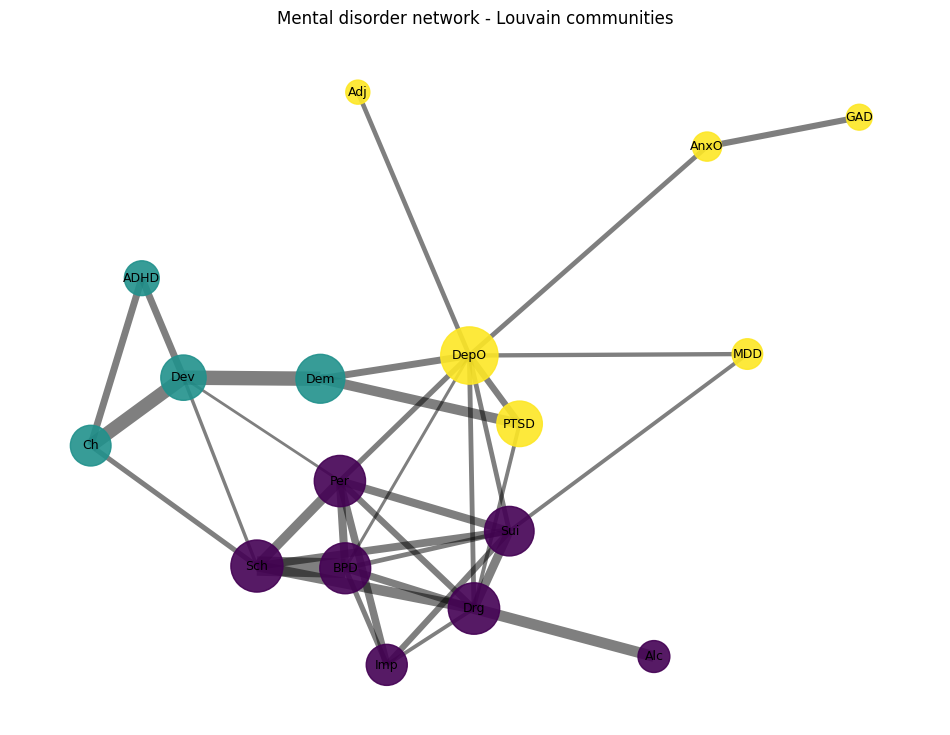

In [ ]:
plot_louvain_graph(
    H_m,
    comms,
    "Mental disorder network - Louvain communities",
    label_map
)

In [ ]:
df_runs_p, df_summary_p, comms_lookup_p = louvain_sweep(H_p, resolutions, seeds)

rep_labels_p, rep_choice_p = representative_labels_by_resolution(df_runs_p, comms_lookup_p, H_p)

chosen_res_p = 1.0   # or whichever resolution you selected for the physical subgraph
sub_p = df_runs_p[np.isclose(df_runs_p["resolution"], chosen_res_p)].copy()

best_row_p = sub_p.sort_values("modularity", ascending=False).iloc[0]
best_seed_p = int(best_row_p["seed"])
chosen_res_used_p = float(best_row_p["resolution"])

comms_p = comms_lookup_p[(chosen_res_used_p, best_seed_p)]

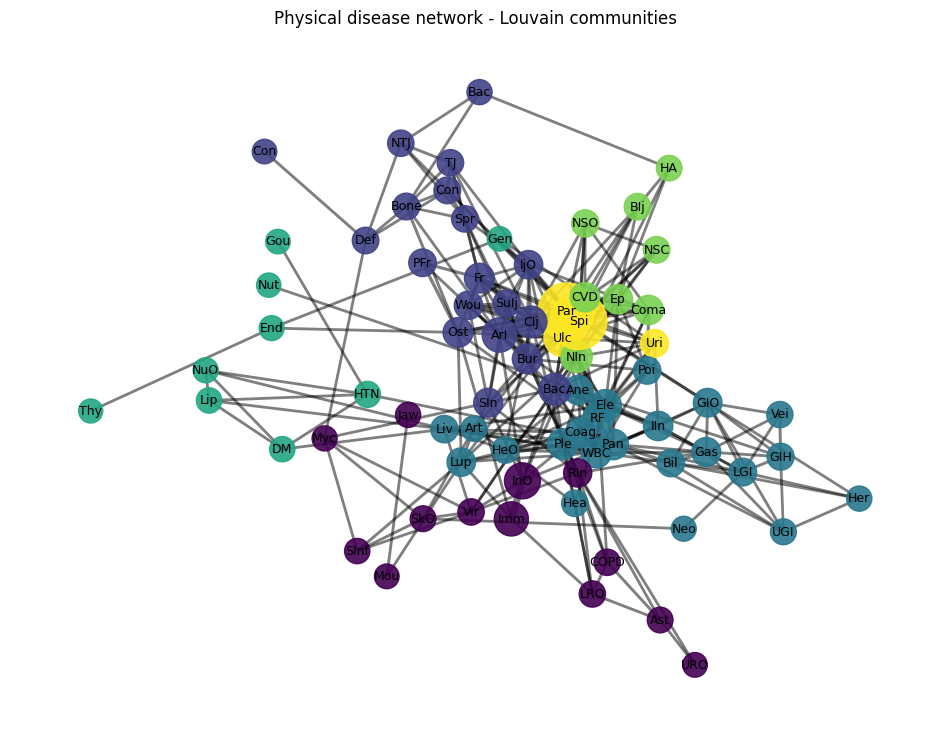

In [ ]:
plot_louvain_graph(
    H_p,
    comms_p,
    "Physical disease network - Louvain communities",
    label_map
)